# Walmart Retail Demand Forecasting & Inventory Optimization

**Goal:** Forecast weekly store/department sales and translate forecast accuracy into estimated inventory cost savings for a retail business.

In [1]:
import pandas as pd
from sqlalchemy import create_engine



## Step 1: Load & Understand the Data

In [2]:
train = pd.read_csv('/Users/bijaybhat/Downloads/train.csv')
stores = pd.read_csv('/Users/bijaybhat/Downloads/stores.csv')
test = pd.read_csv('/Users/bijaybhat/Downloads/test.csv')


In [3]:
print("TRAIN HEAD:")
display(train.head())

print("TRAIN SHAPE:")
print(train.shape)

print("\nTRAIN INFO:")
train.info()

print("\nTRAIN DESCRIBE:")
display(train.describe())

TRAIN HEAD:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


TRAIN SHAPE:
(421570, 5)

TRAIN INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

TRAIN DESCRIBE:


,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [4]:
print("store head:")
display(stores.head())

print("store shape:")
display(stores.shape)

print("store info:")
display(stores.info())

print("store describe:")
display(stores.describe())

store head:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


store shape:


(45, 3)

store info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


None

store describe:


,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


In [5]:
print("Date range:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nNumber of stores:")
print(train["Store"].nunique())

print("\nNumber of departments:")
print(train["Dept"].nunique())

print("\nMissing values:")
print(train.isnull().sum())

print("\nNegative sales:")
print((train["Weekly_Sales"] < 0).sum())

print("\nHoliday weeks:")
print(train["IsHoliday"].value_counts())

Date range:
2010-02-05 to 2012-10-26

Number of stores:
45

Number of departments:
81

Missing values:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Negative sales:
1285

Holiday weeks:
IsHoliday
False    391909
True      29661
Name: count, dtype: int64


## Step 2: Clean the Data

Key findings: 1,285 negative sales values (return-driven weeks, clipped to 0 for modeling), extreme values validated against known holiday spikes (Black Friday, Christmas Eve) rather than treated as errors, and 164 sparse store/department combinations identified.

In [6]:
print("Negative sales summary:")
display(train[train["Weekly_Sales"] < 0]["Weekly_Sales"].describe())

print("\nLargest negative sales:")
display(
    train[train["Weekly_Sales"] < 0]
    .sort_values("Weekly_Sales")
    .head(10)
)

print("\nNegative sales by department:")
display(
    train[train["Weekly_Sales"] < 0]
    .groupby("Dept")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Negative sales summary:


count    1285.000000
mean      -68.608218
std       231.664245
min     -4988.940000
25%       -41.000000
50%       -13.200000
75%        -4.940000
max        -0.020000
Name: Weekly_Sales, dtype: float64


Largest negative sales:


,Store,Dept,Date,Weekly_Sales,IsHoliday
267730,28,6,2010-10-08,-4988.94,False
336495,35,47,2011-09-02,-3924.00,False
417801,45,47,2010-02-26,-1750.00,False
153916,16,47,2012-03-09,-1699.00,False
271300,28,32,2011-03-25,-1321.48,False
16297,2,47,2010-11-19,-1098.00,False
16295,2,47,2010-10-15,-1098.00,False
16291,2,47,2010-07-30,-1098.00,False
24830,3,32,2011-09-30,-1008.96,False
35561,4,47,2010-09-17,-898.00,False



Negative sales by department:


Dept
47    254
18    180
54    146
19     87
94     77
80     68
49     67
59     44
72     34
78     33
dtype: int64

In [7]:
# Missing values check
print(train.isnull().sum())
print(stores.isnull().sum())

# Data types sanity check
print(train.dtypes)

# Duplicate check
print("Duplicate rows:", train.duplicated().sum())

# Basic stats
train['Weekly_Sales'].describe()

# Confirm date range and frequency
train['Date'] = pd.to_datetime(train['Date'])
print(train['Date'].min(), train['Date'].max())
print(train['Date'].dt.dayofweek.unique())  # should all be same weekday if weekly data

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Store    0
Type     0
Size     0
dtype: int64
Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object
Duplicate rows: 0
2010-02-05 00:00:00 2012-10-26 00:00:00
[4]


In [8]:
train['Weekly_Sales_Clipped'] = train['Weekly_Sales'].clip(lower=0)
print(f"Negative values clipped: {(train['Weekly_Sales'] < 0).sum()}")

Negative values clipped: 1285


In [9]:
dupe_keys = train.duplicated(subset=['Store', 'Dept', 'Date']).sum()
print("Duplicate Store/Dept/Date combos:", dupe_keys)

Duplicate Store/Dept/Date combos: 0


In [10]:
train['Weekly_Sales'].describe()

# Look at the top 10 highest sales weeks
train.sort_values('Weekly_Sales', ascending=False).head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Weekly_Sales_Clipped
95373,10,72,2010-11-26,693099.36,True,693099.36
338013,35,72,2011-11-25,649770.18,True,649770.18
95425,10,72,2011-11-25,630999.19,True,630999.19
337961,35,72,2010-11-26,627962.93,True,627962.93
135665,14,72,2010-11-26,474330.10,True,474330.10
195088,20,72,2010-11-26,422306.25,True,422306.25
264390,27,72,2010-11-26,420586.57,True,420586.57
88428,10,7,2010-12-24,406988.63,False,406988.63
95377,10,72,2010-12-24,404245.03,False,404245.03
214432,22,72,2010-11-26,393705.20,True,393705.20


In [11]:
# Coverage check — does every store/dept combo have reasonably complete history?
coverage = train.groupby(['Store', 'Dept'])['Date'].count()
print(coverage.describe())
print("\nStore/Dept combos with fewer than 10 weeks of data:", (coverage < 10).sum())

# IsHoliday distribution
print(train['IsHoliday'].value_counts())

count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
Name: Date, dtype: float64

Store/Dept combos with fewer than 10 weeks of data: 164
IsHoliday
False    391909
True      29661
Name: count, dtype: int64


## Step 3: Combine Train + Stores

In [12]:
train_full = train.merge(stores, on='Store', how='left')

print(train_full.shape)
print(train_full.isnull().sum())  # confirm merge didn't introduce nulls
train_full.head()

(421570, 8)
Store                   0
Dept                    0
Date                    0
Weekly_Sales            0
IsHoliday               0
Weekly_Sales_Clipped    0
Type                    0
Size                    0
dtype: int64


,Store,Dept,Date,Weekly_Sales,IsHoliday,Weekly_Sales_Clipped,Type,Size
0,1,1,2010-02-05,24924.50,False,24924.50,A,151315
1,1,1,2010-02-12,46039.49,True,46039.49,A,151315
2,1,1,2010-02-19,41595.55,False,41595.55,A,151315
3,1,1,2010-02-26,19403.54,False,19403.54,A,151315
4,1,1,2010-03-05,21827.90,False,21827.90,A,151315


## Step 4: Explore Demand Patterns

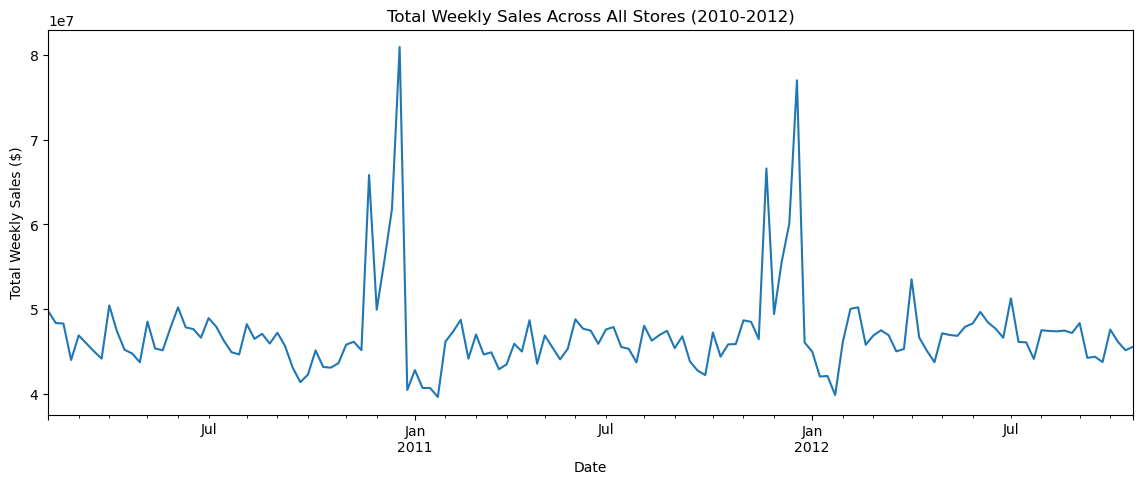

In [13]:
import matplotlib.pyplot as plt

train_full['Date'] = pd.to_datetime(train_full['Date'])

weekly_total = train_full.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14,5))
weekly_total.plot()
plt.title('Total Weekly Sales Across All Stores (2010-2012)')
plt.ylabel('Total Weekly Sales ($)')
plt.show()

In [14]:
holiday_avg = train_full.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median', 'count'])
print(holiday_avg)

                   mean   median   count
IsHoliday                               
False      15901.445069  7589.95  391909
True       17035.823187  7947.74   29661


In [15]:
type_avg = train_full.groupby('Type')['Weekly_Sales'].agg(['mean', 'median', 'sum', 'count'])
print(type_avg)

# Also worth checking: sales per unit of store size (normalizes for store being bigger)
type_size = train_full.groupby('Type').agg({'Weekly_Sales':'mean', 'Size':'mean'})
type_size['sales_per_sqft'] = type_size['Weekly_Sales'] / type_size['Size']
print(type_size)

              mean    median           sum   count
Type                                              
A     20099.568043  10105.17  4.331015e+09  215478
B     12237.075977   6187.87  2.000701e+09  163495
C      9519.532538   1149.67  4.055035e+08   42597
      Weekly_Sales           Size  sales_per_sqft
Type                                             
A     20099.568043  182231.285486        0.110297
B     12237.075977  101818.735827        0.120185
C      9519.532538   40535.725286        0.234843


In [16]:
dept_sales = train_full.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)
print("Top 10 departments:\n", dept_sales.head(10))
print("\nBottom 10 departments:\n", dept_sales.tail(10))

Top 10 departments:
 Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64

Bottom 10 departments:
 Dept
60    2005020.96
54     516294.63
99     358149.85
77      49344.27
45      44937.63
51      30572.83
78       1714.71
39        177.98
43         14.32
47      -4962.93
Name: Weekly_Sales, dtype: float64


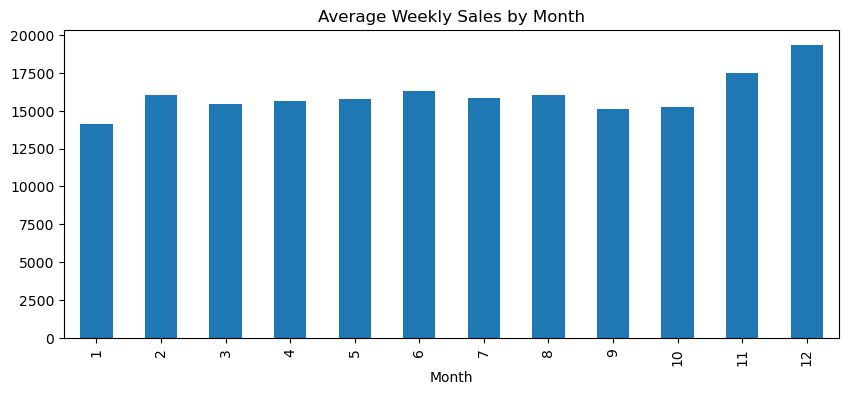

In [17]:
train_full['Month'] = train_full['Date'].dt.month
monthly_avg = train_full.groupby('Month')['Weekly_Sales'].mean()
monthly_avg.plot(kind='bar', figsize=(10,4), title='Average Weekly Sales by Month')
plt.show()

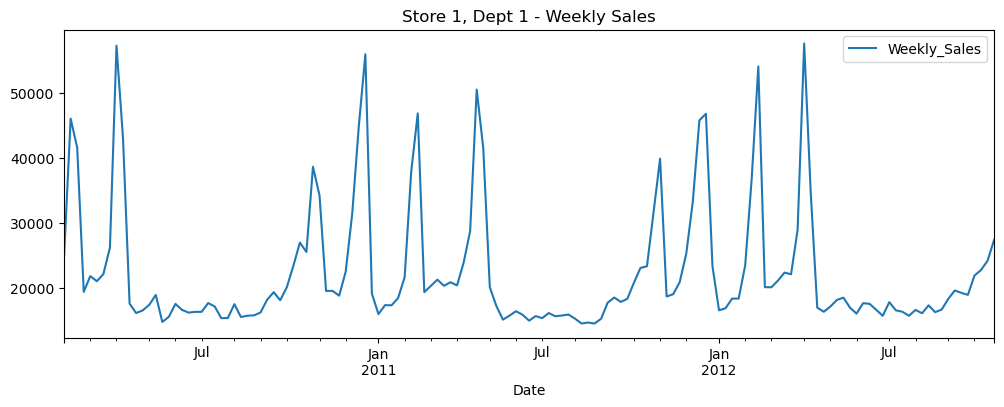

In [18]:
example = train_full[(train_full['Store']==1) & (train_full['Dept']==1)].sort_values('Date')
example.plot(x='Date', y='Weekly_Sales', figsize=(12,4), title='Store 1, Dept 1 - Weekly Sales')
plt.show()

In [19]:
train_full[train_full['Dept']==47]['Weekly_Sales'].describe()
train_full.groupby('Dept')['Store'].nunique().sort_values().head(15)  # depts present in fewest stores

Dept
65     1
43     5
39     5
50    14
37    20
48    25
58    34
99    37
45    37
51    37
54    37
30    37
78    37
77    37
47    37
Name: Store, dtype: int64

## Step 5: Feature Engineering

Built lag features (1-week, 52-week), rolling averages, and explicit holiday-proximity features to address the finding that the raw `IsHoliday` flag understates the two biggest sales weeks of the year.

In [20]:
df = train_full.copy()

# Time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Specific holiday flags (since IsHoliday alone understates Nov/Dec importance)
df['IsThanksgivingWeek'] = df['Date'].isin(pd.to_datetime(['2010-11-26','2011-11-25','2012-11-23']))
df['IsChristmasWeek'] = df['Date'].isin(pd.to_datetime(['2010-12-24','2011-12-23','2012-12-21']))

# Days until Christmas (captures the pre-holiday ramp-up your trend chart shows)
def days_to_christmas(date):
    year = date.year
    christmas = pd.Timestamp(f'{year}-12-25')
    if date > christmas:
        christmas = pd.Timestamp(f'{year+1}-12-25')
    return (christmas - date).days
df['DaysToChristmas'] = df['Date'].apply(days_to_christmas)

# Lag features — last week's and last year's sales for the same store/dept
df = df.sort_values(['Store','Dept','Date'])
df['Sales_Lag1'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
df['Sales_Lag52'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(52)  # same week last year

# Rolling average (recent trend)
df['Sales_RollingMean4'] = df.groupby(['Store','Dept'])['Weekly_Sales'].transform(lambda x: x.rolling(4, min_periods=1).mean())

# One-hot encode store Type
df = pd.get_dummies(df, columns=['Type'], prefix='StoreType')

print(df.shape)
df.head()

(421570, 19)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Weekly_Sales_Clipped,Size,Month,Year,WeekOfYear,IsThanksgivingWeek,IsChristmasWeek,DaysToChristmas,Sales_Lag1,Sales_Lag52,Sales_RollingMean4,StoreType_A,StoreType_B,StoreType_C
0,1,1,2010-02-05,24924.50,False,24924.50,151315,2,2010,5,False,False,323,NaN,NaN,24924.500000,True,False,False
1,1,1,2010-02-12,46039.49,True,46039.49,151315,2,2010,6,False,False,316,24924.50,NaN,35481.995000,True,False,False
2,1,1,2010-02-19,41595.55,False,41595.55,151315,2,2010,7,False,False,309,46039.49,NaN,37519.846667,True,False,False
3,1,1,2010-02-26,19403.54,False,19403.54,151315,2,2010,8,False,False,302,41595.55,NaN,32990.770000,True,False,False
4,1,1,2010-03-05,21827.90,False,21827.90,151315,3,2010,9,False,False,295,19403.54,NaN,32216.620000,True,False,False


In [21]:
print("Sales_Lag1 NaNs:", df['Sales_Lag1'].isnull().sum())
print("Sales_Lag52 NaNs:", df['Sales_Lag52'].isnull().sum())

# Expected: Lag1 NaNs = number of unique store/dept combos (each series' first week has no prior week)
print("Unique Store/Dept combos:", df.groupby(['Store','Dept']).ngroups)

Sales_Lag1 NaNs: 3331
Sales_Lag52 NaNs: 160487
Unique Store/Dept combos: 3331


In [22]:
# Fill Sales_Lag1 with rolling mean as fallback
df['Sales_Lag1'] = df['Sales_Lag1'].fillna(df['Sales_RollingMean4'])

# Leave Sales_Lag52 as NaN for now — we'll handle it explicitly during train/test split in Step 6/8
print(df.isnull().sum())

Store                        0
Dept                         0
Date                         0
Weekly_Sales                 0
IsHoliday                    0
Weekly_Sales_Clipped         0
Size                         0
Month                        0
Year                         0
WeekOfYear                   0
IsThanksgivingWeek           0
IsChristmasWeek              0
DaysToChristmas              0
Sales_Lag1                   0
Sales_Lag52             160487
Sales_RollingMean4           0
StoreType_A                  0
StoreType_B                  0
StoreType_C                  0
dtype: int64


## Step 6: Baseline Forecast

Naive (last week) and seasonal-naive (same week last year) baselines, evaluated with Weighted MAE (holiday weeks weighted 5x), matching the metric from the original Kaggle competition.

In [23]:
# Use last ~12 weeks as test set (roughly last 3 months)
cutoff_date = df['Date'].max() - pd.Timedelta(weeks=12)

train_set = df[df['Date'] <= cutoff_date].copy()
test_set = df[df['Date'] > cutoff_date].copy()

print("Train:", train_set.shape, train_set['Date'].max())
print("Test:", test_set.shape, test_set['Date'].min(), "-", test_set['Date'].max())

Train: (386007, 19) 2012-08-03 00:00:00
Test: (35563, 19) 2012-08-10 00:00:00 - 2012-10-26 00:00:00


In [24]:
test_set['Baseline_NaiveLastWeek'] = test_set['Sales_Lag1']

In [25]:
test_set['Baseline_SameWeekLastYear'] = test_set['Sales_Lag52']

import numpy as np

def wmae(y_true, y_pred, weights):
    return np.average(np.abs(y_true - y_pred), weights=weights)

test_set['weight'] = np.where(test_set['IsHoliday'], 5, 1)

for baseline_col in ['Baseline_NaiveLastWeek', 'Baseline_SameWeekLastYear']:
    valid = test_set.dropna(subset=[baseline_col])
    mae = np.mean(np.abs(valid['Weekly_Sales'] - valid[baseline_col]))
    w_mae = wmae(valid['Weekly_Sales'], valid[baseline_col], valid['weight'])
    print(f"{baseline_col}: MAE=${mae:,.2f}, WMAE=${w_mae:,.2f}, n={len(valid)}")

Baseline_NaiveLastWeek: MAE=$1,500.23, WMAE=$1,653.46, n=35563
Baseline_SameWeekLastYear: MAE=$1,764.25, WMAE=$1,784.56, n=34967


## Step 7: Train ML Model

XGBoost regressor, achieving a 33.8% reduction in WMAE vs. the naive baseline.

In [26]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# Define features to use (exclude identifiers, target, and leakage-prone columns)
feature_cols = [
    'Store', 'Dept', 'IsHoliday', 'Size', 'Month', 'Year', 'WeekOfYear',
    'IsThanksgivingWeek', 'IsChristmasWeek', 'DaysToChristmas',
    'Sales_Lag1', 'Sales_Lag52', 'Sales_RollingMean4',
    'StoreType_A', 'StoreType_B', 'StoreType_C'
]

X_train = train_set[feature_cols]
y_train = train_set['Weekly_Sales']

X_test = test_set[feature_cols]
y_test = test_set['Weekly_Sales']

# XGBoost handles NaNs natively (e.g., in Sales_Lag52) — no need to impute
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
w_mae = wmae(y_test, preds, test_set['weight'])

print(f"XGBoost: MAE=${mae:,.2f}, WMAE=${w_mae:,.2f}")
print(f"Baseline (naive last week) WMAE was: $1,653.46")
print(f"Improvement: {(1653.46 - w_mae) / 1653.46 * 100:.1f}%")

XGBoost: MAE=$1,039.66, WMAE=$1,093.92
Baseline (naive last week) WMAE was: $1,653.46
Improvement: 33.8%


In [27]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

               feature  importance
12  Sales_RollingMean4    0.864230
7   IsThanksgivingWeek    0.045477
8      IsChristmasWeek    0.038512
11         Sales_Lag52    0.009400
10          Sales_Lag1    0.009385
9      DaysToChristmas    0.007831
1                 Dept    0.006693
6           WeekOfYear    0.003065
2            IsHoliday    0.003038
5                 Year    0.002791
4                Month    0.002518
3                 Size    0.002490
0                Store    0.002262
15         StoreType_C    0.001258
14         StoreType_B    0.000563
13         StoreType_A    0.000488


In [28]:
feature_cols_no_rolling = [f for f in feature_cols if f != 'Sales_RollingMean4']

X_train2 = train_set[feature_cols_no_rolling]
X_test2 = test_set[feature_cols_no_rolling]

model2 = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
model2.fit(X_train2, y_train)
preds2 = model2.predict(X_test2)

mae2 = mean_absolute_error(y_test, preds2)
w_mae2 = wmae(y_test, preds2, test_set['weight'])
print(f"XGBoost (no rolling mean): MAE=${mae2:,.2f}, WMAE=${w_mae2:,.2f}")

XGBoost (no rolling mean): MAE=$1,253.28, WMAE=$1,302.24


## Step 8: Explainability (SHAP)

Key finding: the model relies primarily on recent sales momentum (`Sales_RollingMean4`), with holiday flags providing a secondary correction — a limitation worth noting for holiday-period accuracy.

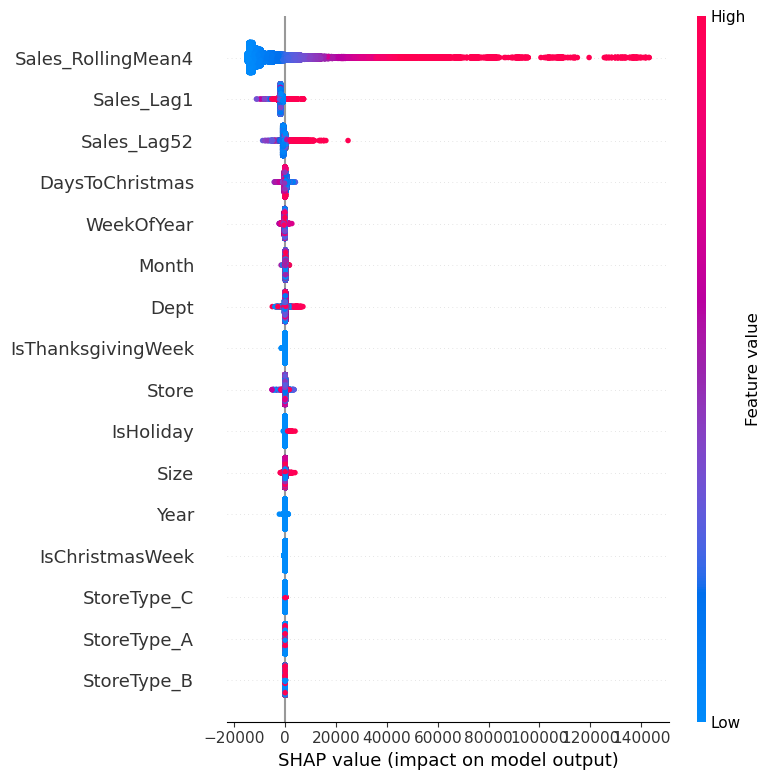

In [29]:
import shap

# Refit or reuse your original full model
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot - shows feature importance AND direction of effect
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

## Step 9: Inventory Cost Simulation

Translated forecast error into estimated dollar cost under assumed holding/stockout rates — ~30% estimated cost reduction, stable across a sensitivity analysis.

In [30]:
# Assumptions (state these explicitly in your README)
HOLDING_COST_PER_DOLLAR_OVER = 0.10   # cost of overstocking, per $ of excess forecasted inventory
STOCKOUT_COST_PER_DOLLAR_UNDER = 0.25 # cost of understocking, per $ of missed demand (lost sales + customer dissatisfaction)

test_set = test_set.copy()
test_set['XGB_Pred'] = preds

def inventory_cost(actual, predicted, holding_cost, stockout_cost):
    error = predicted - actual
    over = np.where(error > 0, error, 0)   # overstocked
    under = np.where(error < 0, -error, 0) # understocked
    return (over * holding_cost + under * stockout_cost)

test_set['Cost_XGB'] = inventory_cost(test_set['Weekly_Sales'], test_set['XGB_Pred'], HOLDING_COST_PER_DOLLAR_OVER, STOCKOUT_COST_PER_DOLLAR_UNDER)
test_set['Cost_Naive'] = inventory_cost(test_set['Weekly_Sales'], test_set['Baseline_NaiveLastWeek'], HOLDING_COST_PER_DOLLAR_OVER, STOCKOUT_COST_PER_DOLLAR_UNDER)

total_cost_xgb = test_set['Cost_XGB'].sum()
total_cost_naive = test_set['Cost_Naive'].sum()

print(f"Estimated inventory cost (XGBoost model): ${total_cost_xgb:,.0f}")
print(f"Estimated inventory cost (Naive baseline): ${total_cost_naive:,.0f}")
print(f"Estimated savings: ${total_cost_naive - total_cost_xgb:,.0f} ({(total_cost_naive-total_cost_xgb)/total_cost_naive*100:.1f}%)")

Estimated inventory cost (XGBoost model): $6,410,163
Estimated inventory cost (Naive baseline): $9,190,915
Estimated savings: $2,780,752 (30.3%)


In [31]:
scenarios = [
    (0.05, 0.15, "Low cost scenario"),
    (0.10, 0.25, "Base case (current)"),
    (0.15, 0.40, "High cost scenario"),
    (0.10, 0.50, "High stockout penalty (e.g. high-margin goods)"),
]

print(f"{'Scenario':<40}{'XGB Cost':>15}{'Naive Cost':>15}{'Savings %':>12}")
for holding, stockout, label in scenarios:
    cost_xgb = inventory_cost(test_set['Weekly_Sales'], test_set['XGB_Pred'], holding, stockout).sum()
    cost_naive = inventory_cost(test_set['Weekly_Sales'], test_set['Baseline_NaiveLastWeek'], holding, stockout).sum()
    savings_pct = (cost_naive - cost_xgb) / cost_naive * 100
    print(f"{label:<40}${cost_xgb:>13,.0f}${cost_naive:>14,.0f}{savings_pct:>11.1f}%")

Scenario                                       XGB Cost     Naive Cost   Savings %
Low cost scenario                       $    3,657,220$     5,238,064       30.2%
Base case (current)                     $    6,410,163$     9,190,915       30.3%
High cost scenario                      $   10,067,382$    14,428,979       30.2%
High stockout penalty (e.g. high-margin goods)$   10,931,545$    15,616,982       30.0%


## Step 10: Save Artifacts for Dashboard

Model and processed data exported for the Streamlit dashboard (see `app.py`).

In [32]:
import joblib

# Save model
joblib.dump(model, 'model.pkl')

# Save the test set with predictions (for the app to use directly)
test_set.to_csv('test_set_with_preds.csv', index=False)

# Save training set summary (for store/dept dropdown + history charts)
df.to_csv('full_data_with_features.csv', index=False)

print("Saved model.pkl, test_set_with_preds.csv, full_data_with_features.csv")

Saved model.pkl, test_set_with_preds.csv, full_data_with_features.csv


In [70]:
cols_needed = ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Month', 
               'StoreType_A', 'StoreType_B', 'StoreType_C']
df[cols_needed].to_csv('/Users/bijaybhat/full_data_light.csv', index=False)

import os
size_mb = os.path.getsize('/Users/bijaybhat/full_data_light.csv') / (1024*1024)
print(f"Size: {size_mb:.2f} MB")

Size: 20.03 MB
